# SCALABILITY ANALYSIS

In [ ]:
# Only 3 fractions instead of 5, LR only

print("SCALABILITY ANALYSIS")

fractions     = [0.25, 0.5, 1.0]
scale_results = []

evaluator_scale = BinaryClassificationEvaluator(
    labelCol="arrest",
    metricName="areaUnderROC"
)

print("Strong Scaling - Fixed model, increasing data size")
print("Model: Logistic Regression (maxIter=10 for speed)")

for frac in fractions:
    sample = train_df.sample(fraction=frac, seed=42)
    n_rows = sample.count()

    lr_scale = LogisticRegression(
        labelCol="arrest",
        featuresCol="features",
        maxIter=10,
        regParam=0.01
    )

    start   = time.time()
    mdl     = lr_scale.fit(sample)
    preds   = mdl.transform(test_df)
    elapsed = round(time.time() - start, 2)
    auc     = round(evaluator_scale.evaluate(preds), 4)

    scale_results.append({
        "fraction"       : frac,
        "rows_used"      : n_rows,
        "train_time_sec" : elapsed,
        "auc"            : auc,
        "scaling_type"   : "Strong Scaling"
    })
    print(f"  {frac:.0%} | {n_rows:>10,} rows | {elapsed}s | AUC: {auc}")

    # Unpersist after each iteration
    sample.unpersist()
    del mdl, preds
    gc.collect()

print("\nWeak Scaling - Data and model complexity grow together")

for frac in fractions:
    sample  = train_df.sample(fraction=frac, seed=42)
    n_rows  = sample.count()
    n_trees = max(10, int(30 * frac))

    rf_scale = RandomForestClassifier(
        labelCol="arrest",
        featuresCol="features",
        numTrees=n_trees,
        maxDepth=5,
        seed=42
    )

    start   = time.time()
    mdl     = rf_scale.fit(sample)
    preds   = mdl.transform(test_df)
    elapsed = round(time.time() - start, 2)
    auc     = round(evaluator_scale.evaluate(preds), 4)

    scale_results.append({
        "fraction"       : frac,
        "rows_used"      : n_rows,
        "train_time_sec" : elapsed,
        "auc"            : auc,
        "scaling_type"   : "Weak Scaling"
    })
    print(f"  {frac:.0%} | {n_rows:>10,} rows | Trees: {n_trees} | {elapsed}s | AUC: {auc}")

    sample.unpersist()
    del mdl, preds
    gc.collect()

scale_df = pd.DataFrame(scale_results)
print("\nScalability Summary:")
print(scale_df.to_string(index=False))

scale_df.to_csv(
    f"{TABLEAU_DIR}/tableau_scalability.csv", index=False
)
print("\nTableau Dashboard 4 file saved")

# Final check of all Tableau files
print("ALL TABLEAU FILES")
for f in sorted(os.listdir(TABLEAU_DIR)):
    size = os.path.getsize(
        os.path.join(TABLEAU_DIR, f)
    ) / 1024
    print(f"  {f:45s} {size:.1f} KB")

SCALABILITY ANALYSIS
Strong Scaling - Fixed model, increasing data size
Model: Logistic Regression (maxIter=10 for speed)
  25% |    951,624 rows | 10.54s | AUC: 0.8786
  50% |  1,900,218 rows | 27.38s | AUC: 0.8794
  100% |  3,797,546 rows | 31.48s | AUC: 0.8806

Weak Scaling - Data and model complexity grow together
  25% |    951,624 rows | Trees: 10 | 41.77s | AUC: 0.8178
  50% |  1,900,218 rows | Trees: 15 | 113.51s | AUC: 0.8087
  100% |  3,797,546 rows | Trees: 30 | 348.4s | AUC: 0.8415

Scalability Summary:
 fraction  rows_used  train_time_sec    auc   scaling_type
     0.25     951624           10.54 0.8786 Strong Scaling
     0.50    1900218           27.38 0.8794 Strong Scaling
     1.00    3797546           31.48 0.8806 Strong Scaling
     0.25     951624           41.77 0.8178   Weak Scaling
     0.50    1900218          113.51 0.8087   Weak Scaling
     1.00    3797546          348.40 0.8415   Weak Scaling

Tableau Dashboard 4 file saved
ALL TABLEAU FILES
  tableau_crime_

In [ ]:
# Feature Importance from Random Forest
feature_importances = rf_model.featureImportances
numeric_features = [
    'beat', 'district', 'ward', 'community_area',
    'latitude', 'longitude', 'hour_of_day',
    'day_of_week', 'month_of_year', 'domestic', 'year'
]

# Get importance scores for numeric features only
# (encoded features have variable indices)
importance_data = []
for i, name in enumerate(numeric_features):
    if i < len(feature_importances):
        importance_data.append({
            "feature"    : name,
            "importance" : round(float(feature_importances[i]), 6)
        })

importance_df = pd.DataFrame(importance_data)
importance_df = importance_df.sort_values(
    "importance", ascending=False
)

print("\nTop 10 Important Features:")
print(importance_df.head(10).to_string(index=False))

importance_df.to_csv(
    f"{TABLEAU_DIR}/tableau_feature_importance.csv", index=False
)
print("\nFeature importance saved for Tableau Dashboard 2")


Top 10 Important Features:
       feature  importance
      domestic    0.004929
   hour_of_day    0.004697
      latitude    0.001642
          ward    0.001433
          year    0.000880
community_area    0.000759
          beat    0.000285
     longitude    0.000235
      district    0.000232
 month_of_year    0.000068

Feature importance saved for Tableau Dashboard 2


In [ ]:

#  Confusion Matrix Data for all models

def get_confusion_matrix(predictions, model_name):
    tp = predictions.filter(
        (col("arrest") == 1) & (col("prediction") == 1)
    ).count()
    tn = predictions.filter(
        (col("arrest") == 0) & (col("prediction") == 0)
    ).count()
    fp = predictions.filter(
        (col("arrest") == 0) & (col("prediction") == 1)
    ).count()
    fn = predictions.filter(
        (col("arrest") == 1) & (col("prediction") == 0)
    ).count()

    total = tp + tn + fp + fn
    print(f"\n{model_name}")
    print(f"  TP: {tp:,}  FP: {fp:,}")
    print(f"  FN: {fn:,}  TN: {tn:,}")
    print(f"  Specificity : {tn/(tn+fp):.4f}")
    print(f"  Sensitivity : {tp/(tp+fn):.4f}")

    return {
        "model"       : model_name,
        "TP"          : tp,
        "TN"          : tn,
        "FP"          : fp,
        "FN"          : fn,
        "specificity" : round(tn/(tn+fp), 4),
        "sensitivity" : round(tp/(tp+fn), 4)
    }

cm_results = []
cm_results.append(get_confusion_matrix(lr_preds,  "Logistic Regression"))
cm_results.append(get_confusion_matrix(rf_preds,  "Random Forest"))
cm_results.append(get_confusion_matrix(gbt_preds, "Gradient Boosted Trees"))
cm_results.append(get_confusion_matrix(svm_preds, "Linear SVM"))

cm_df = pd.DataFrame(cm_results)
cm_df.to_csv(
    f"{TABLEAU_DIR}/tableau_confusion_matrix.csv", index=False
)
print("\nConfusion matrix data saved for Tableau")


Logistic Regression
  TP: 29,186  FP: 11,110
  FN: 25,708  TN: 383,648
  Specificity : 0.9719
  Sensitivity : 0.5317

Random Forest
  TP: 21,431  FP: 1,062
  FN: 33,463  TN: 393,696
  Specificity : 0.9973
  Sensitivity : 0.3904

Gradient Boosted Trees
  TP: 27,222  FP: 10,307
  FN: 27,672  TN: 384,451
  Specificity : 0.9739
  Sensitivity : 0.4959

Linear SVM
  TP: 30,152  FP: 18,699
  FN: 24,742  TN: 376,059
  Specificity : 0.9526
  Sensitivity : 0.5493

Confusion matrix data saved for Tableau


In [ ]:
# ROC Curve Data


from pyspark.ml.evaluation import BinaryClassificationEvaluator

def get_roc_data(predictions, model_name):
    # Sample predictions for ROC curve points
    roc_sample = predictions.select(
        "arrest",
        "probability"
    ).sample(fraction=0.05, seed=42).toPandas()

    roc_sample["prob_positive"] = roc_sample["probability"].apply(
        lambda x: float(x[1])
    )
    roc_sample["model"] = model_name

    return roc_sample[["arrest", "prob_positive", "model"]]

# SVM does not have probability so skip it
roc_lr  = get_roc_data(lr_preds,  "Logistic Regression")
roc_rf  = get_roc_data(rf_preds,  "Random Forest")
roc_gbt = get_roc_data(gbt_preds, "Gradient Boosted Trees")

roc_all = pd.concat([roc_lr, roc_rf, roc_gbt], ignore_index=True)
roc_all.to_csv(
    f"{TABLEAU_DIR}/tableau_roc_data.csv", index=False
)
print(f"ROC data saved — {len(roc_all):,} sample points")

ROC data saved — 66,942 sample points


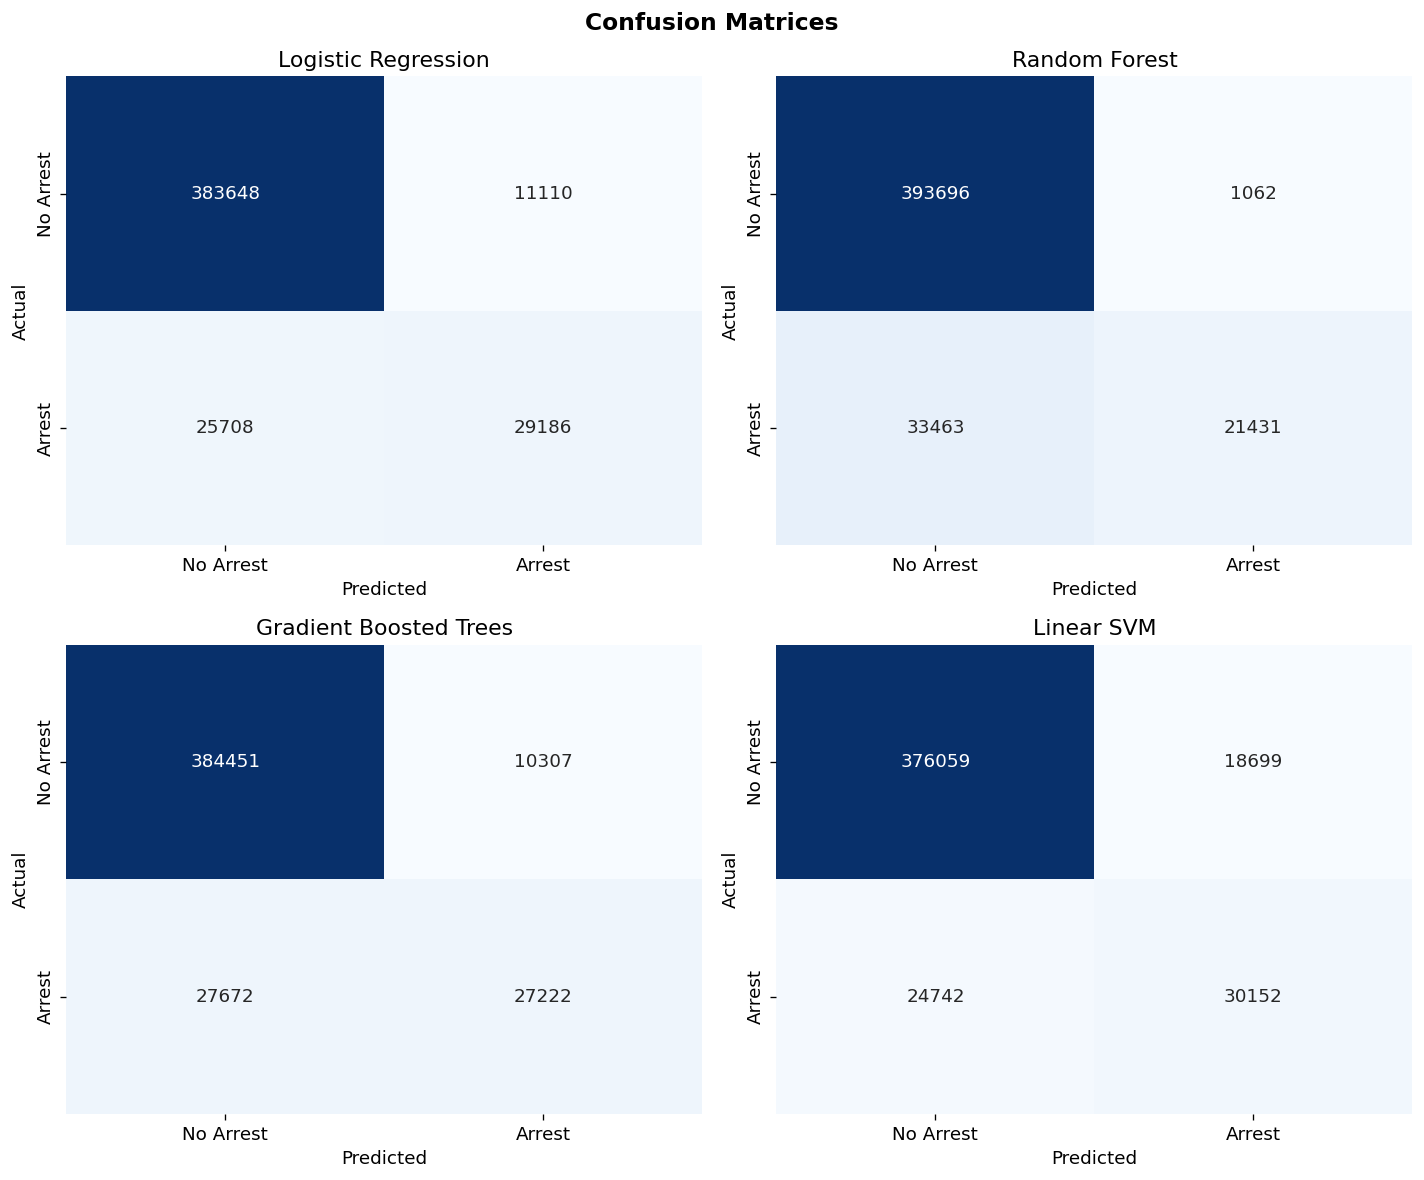

Saved: confusion_matrices.png


In [ ]:

#  Confusion Matrices (all 4 models)

def get_cm_data(preds_df):
    pdf = preds_df.select("arrest", "prediction").toPandas()
    return confusion_matrix(pdf["arrest"], pdf["prediction"])

model_preds = [
    (lr_preds,  "Logistic Regression"),
    (rf_preds,  "Random Forest"),
    (gbt_preds, "Gradient Boosted Trees"),
    (svm_preds, "Linear SVM")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")

for ax, (preds, name) in zip(axes.flatten(), model_preds):
    cm = get_cm_data(preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        ax=ax, cbar=False,
        xticklabels=["No Arrest", "Arrest"],
        yticklabels=["No Arrest", "Arrest"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()
print("Saved: confusion_matrices.png")

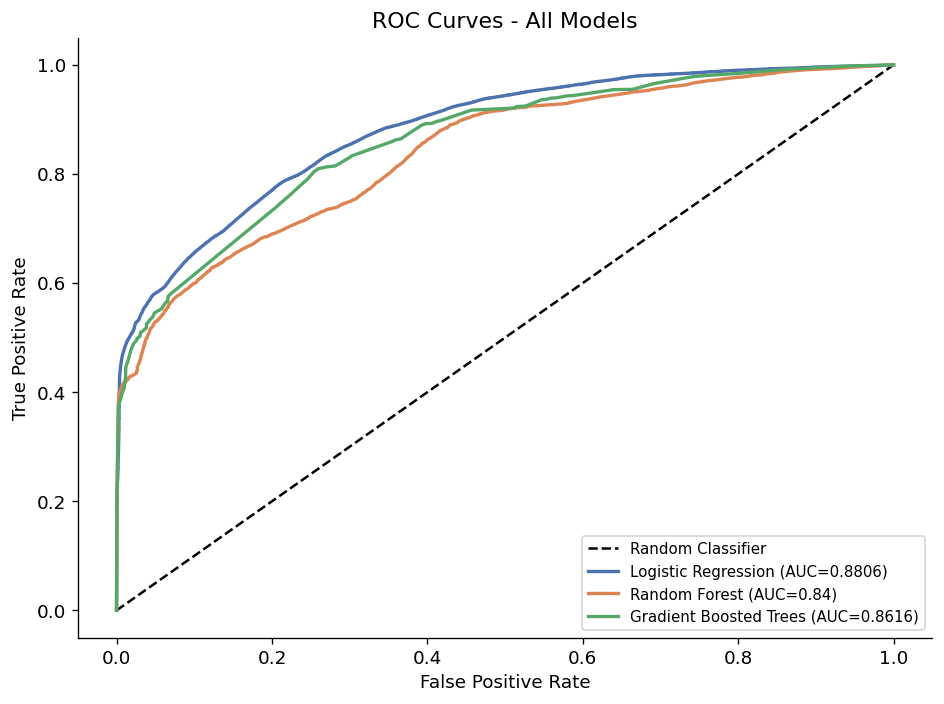

In [ ]:
# ROC Curves (all 4 models)


def get_roc_data(preds_df):
    pdf  = preds_df.select("arrest", "probability").toPandas()
    prob = pdf["probability"].apply(lambda x: float(x[1]))
    fpr, tpr, _ = roc_curve(pdf["arrest"], prob)
    return fpr, tpr

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")

roc_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

roc_models = [
    (lr_preds,  "Logistic Regression", lr_results["auc"]),
    (rf_preds,  "Random Forest",       rf_results["auc"]),
    (gbt_preds, "Gradient Boosted Trees", gbt_results["auc"]),
]
# SVM does not have probability - skip from ROC

for (preds, name, auc), color in zip(roc_models, roc_colors):
    fpr, tpr = get_roc_data(preds)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC={auc})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:

# Crime Trends Over Years

arrest_trend = df_processed \
    .groupBy("year", "arrest") \
    .count() \
    .orderBy("year") \
    .toPandas()

arrest_trend.to_csv(
    f"{TABLEAU_DIR}/tableau_arrest_trend.csv", index=False
)

# Top crime types for business insights
top_crimes = df_processed \
    .groupBy("primary_type", "arrest") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(100) \
    .toPandas()

top_crimes.to_csv(
    f"{TABLEAU_DIR}/tableau_top_crimes.csv", index=False
)

# Location based analysis
location_crimes = df_processed \
    .groupBy("location_description") \
    .agg(
        F.count("*").alias("total_crimes"),
        F.sum("arrest").alias("total_arrests")
    ) \
    .withColumn(
        "arrest_rate",
        F.round(F.col("total_arrests") / F.col("total_crimes"), 3)
    ) \
    .orderBy("total_crimes", ascending=False) \
    .limit(50) \
    .toPandas()

location_crimes.to_csv(
    f"{TABLEAU_DIR}/tableau_location_analysis.csv", index=False
)

# District level summary
district_crimes = df_processed \
    .groupBy("district") \
    .agg(
        F.count("*").alias("total_crimes"),
        F.sum("arrest").alias("total_arrests"),
        F.round(
            F.sum("arrest") / F.count("*"), 3
        ).alias("arrest_rate")
    ) \
    .orderBy("total_crimes", ascending=False) \
    .toPandas()

district_crimes.to_csv(
    f"{TABLEAU_DIR}/tableau_district_analysis.csv", index=False
)

print("Tableau Dashboard 3 files saved")

Tableau Dashboard 3 files saved


In [ ]:

# Spark UI & Health Check


print("Spark UI URL:", spark.sparkContext.uiWebUrl)
print("App ID      :", spark.sparkContext.applicationId)
print("App Name    :", spark.sparkContext.appName)
print("Spark Ver   :", spark.version)

# Simplest possible health check - just run a query

spark.sql("SELECT 'Spark is alive' as status").show(truncate=False)

# Check if key DataFrames are still cached
print(" Cached DataFrames ")
for name, df_obj in [("df_ml", df_ml), ("train_df", train_df), ("test_df", test_df)]:
    try:
        level = df_obj.storageLevel
        cached = level.useMemory or level.useDisk
        print(f"  {name:12s}: {'CACHED' if cached else 'NOT CACHED'}")
    except Exception as e:
        print(f"  {name:12s}: ERROR - {e}")

# Check saved files on disk
print("\n Saved Files on Disk ")
import os
for folder in ["/content/chicago_crimes/processed",
               "/content/chicago_crimes/tableau",
               "/content/chicago_crimes/models"]:
    exists = os.path.exists(folder)
    print(f"  {folder.split('/')[-1]:12s}: {'EXISTS' if exists else 'MISSING'}")

Spark UI URL: http://09b9a4b27e60:4040
App ID      : local-1772271897414
App Name    : ChicagoCrimesML
Spark Ver   : 4.0.2
+--------------+
|status        |
+--------------+
|Spark is alive|
+--------------+

 Cached DataFrames 
  df_ml       : CACHED
  train_df    : CACHED
  test_df     : CACHED

 Saved Files on Disk 
  processed   : EXISTS
  tableau     : EXISTS
  models      : EXISTS


In [ ]:
print("Spark UI URL:", spark.sparkContext.uiWebUrl)
print("App ID      :", spark.sparkContext.applicationId)
print("App Name    :", spark.sparkContext.appName)
print("Spark Ver   :", spark.version)

Spark UI URL: http://09b9a4b27e60:4040
App ID      : local-1772271897414
App Name    : ChicagoCrimesML
Spark Ver   : 4.0.2


In [ ]:
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(4040)")
print("Open this in browser:", url)

Open this in browser: https://4040-m-s-3i6mu3xqlzs4-b.us-east1-2.prod.colab.dev


In [ ]:
spark.sql("SELECT 'Spark is alive' as status").show(truncate=False)

for name, df_obj in [("df_ml", df_ml), ("train_df", train_df), ("test_df", test_df)]:
    level = df_obj.storageLevel
    cached = level.useMemory or level.useDisk
    print(f"  {name:12s}: {'CACHED' if cached else 'NOT CACHED'}")

+--------------+
|status        |
+--------------+
|Spark is alive|
+--------------+

  df_ml       : CACHED
  train_df    : CACHED
  test_df     : CACHED


In [ ]:
import os
for folder in ["/content/chicago_crimes/processed",
               "/content/chicago_crimes/tableau",
               "/content/chicago_crimes/models"]:
    exists = os.path.exists(folder)
    print(f"  {folder.split('/')[-1]:12s}: {'EXISTS ' if exists else 'MISSING '}")

  processed   : EXISTS 
  tableau     : EXISTS 
  models      : EXISTS 


In [ ]:
# Install cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
!chmod +x /usr/local/bin/cloudflared

# Start tunnel to Spark UI
import subprocess, re, time

p = subprocess.Popen(
    ["cloudflared", "tunnel", "--url", "http://127.0.0.1:4040"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

# Wait and print the public URL
public_url = None
for _ in range(60):
    line = p.stdout.readline()
    if line:
        m = re.search(r"https://[-\w]+\.trycloudflare\.com", line)
        if m:
            public_url = m.group(0)
            break


print(" Spark UI Public Link:", public_url)
print(" Open this in your browser!")


/usr/local/bin/cloudflared: Text file busy
 Spark UI Public Link: https://timer-emperor-tile-safe.trycloudflare.com
 Open this in your browser!


In [ ]:
#  mount and copy to Drive
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copytree(
    "/content/chicago_crimes",
    "/drive/MyDrive/chicago_crimes",
    dirs_exist_ok=True
)
print("Backed up to Google Drive!")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Backed up to Google Drive!


In [ ]:
# Copy from Drive to local first, then read
!pip install pyspark findspark xgboost --quiet

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count
import pandas as pd
import numpy as np
import os, time, gc, shutil
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
from google.colab import drive
drive.mount('/drive')


# Copy from Drive to local /content/ first
DRIVE_DIR  = "/drive/MyDrive/chicago_crimes"
LOCAL_DIR  = "/content/chicago_crimes"

print("Copying files from Drive to local...")

# Copy processed parquet
if os.path.exists(f"{LOCAL_DIR}/processed"):
    shutil.rmtree(f"{LOCAL_DIR}/processed")
shutil.copytree(
    f"{DRIVE_DIR}/processed",
    f"{LOCAL_DIR}/processed"
)


# Copy tableau folder
if os.path.exists(f"{LOCAL_DIR}/tableau"):
    shutil.rmtree(f"{LOCAL_DIR}/tableau")
shutil.copytree(
    f"{DRIVE_DIR}/tableau",
    f"{LOCAL_DIR}/tableau"
)


# Copy models folder
if os.path.exists(f"{LOCAL_DIR}/models"):
    shutil.rmtree(f"{LOCAL_DIR}/models")
shutil.copytree(
    f"{DRIVE_DIR}/models",
    f"{LOCAL_DIR}/models"
)


# Set paths to LOCAL

PROCESSED_PATH = f"{LOCAL_DIR}/processed"
TABLEAU_DIR    = f"{LOCAL_DIR}/tableau"
MODELS_DIR     = f"{LOCAL_DIR}/models"


# STEP 3 - Start Spark & Load
spark = SparkSession.builder \
    .appName("ChicagoCrimesML") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "100") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

print("\nSpark ready:", spark.version)

# Verify GPU
import subprocess
try:
    print(subprocess.check_output("nvidia-smi", shell=True).decode()[:200])
except:
    print("No GPU found - check runtime type")

# Load from LOCAL path
df_processed = spark.read.parquet(PROCESSED_PATH)
df_processed.cache()
print(" df_processed loaded:", df_processed.count(), "rows")

# Recreate splits
train_df = df_processed.filter(F.col("year") <= 2019).select("features", "arrest")
val_df   = df_processed.filter(F.col("year") == 2020).select("features", "arrest")
test_df  = df_processed.filter(F.col("year") >= 2021).select("features", "arrest")

train_df.cache()
test_df.cache()

print(f"Train : {train_df.count():,}")
print(f"Test  : {test_df.count():,}")


Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Copying files from Drive to local...

Spark ready: 4.0.2
Sat Feb 28 12:45:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Vers
 df_processed loaded: 4459898 rows
Train : 3,797,546
Test  : 449,652


In [ ]:
!pip install xgboost --quiet

import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import subprocess
import time
import gc

In [ ]:
# Check GPU
try:
    gpu_info = subprocess.check_output("nvidia-smi", shell=True).decode()
    gpu_available = True
    print("GPU detected:")
    print(gpu_info[:300])
except:
    gpu_available = False
    print("No GPU detected")

# Prepare data
print("\nPreparing data for XGBoost")
sample_pd = df_processed \
    .select("features", "arrest") \
    .sample(fraction=0.02, seed=42) \
    .limit(30000) \
    .toPandas()

X_xgb = np.array([v.toArray() for v in sample_pd["features"]])
y_xgb = sample_pd["arrest"].values

split      = int(0.8 * len(X_xgb))
X_tr, X_te = X_xgb[:split], X_xgb[split:]
y_tr, y_te = y_xgb[:split], y_xgb[split:]

del sample_pd
gc.collect()

GPU detected:
Sat Feb 28 12:49:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------

Preparing data for XGBoost


27

In [ ]:
# CPU
print("\nXGBoost - CPU Training.")
xgb_cpu = xgb.XGBClassifier(
    n_estimators=100, max_depth=6,
    learning_rate=0.1, device="cpu",
    random_state=42, eval_metric="logloss", verbosity=0
)
start     = time.time()
xgb_cpu.fit(X_tr, y_tr)
cpu_time  = round(time.time() - start, 2)
cpu_preds = xgb_cpu.predict(X_te)
cpu_proba = xgb_cpu.predict_proba(X_te)[:, 1]
cpu_acc   = round(accuracy_score(y_te, cpu_preds), 4)
cpu_auc   = round(roc_auc_score(y_te, cpu_proba), 4)
print(f"  Training time : {cpu_time}s")
print(f"  Accuracy      : {cpu_acc}")
print(f"  AUC-ROC       : {cpu_auc}")


XGBoost - CPU Training.
  Training time : 8.42s
  Accuracy      : 0.8918
  AUC-ROC       : 0.9115


In [ ]:
# GPU
if gpu_available:
    print("\nXGBoost - GPU Training")
    xgb_gpu = xgb.XGBClassifier(
        n_estimators=100, max_depth=6,
        learning_rate=0.1, device="cuda",
        random_state=42, eval_metric="logloss", verbosity=0
    )
    start     = time.time()
    xgb_gpu.fit(X_tr, y_tr)
    gpu_time  = round(time.time() - start, 2)
    gpu_preds = xgb_gpu.predict(X_te)
    gpu_proba = xgb_gpu.predict_proba(X_te)[:, 1]
    gpu_acc   = round(accuracy_score(y_te, gpu_preds), 4)
    gpu_auc   = round(roc_auc_score(y_te, gpu_proba), 4)
    speedup   = round(cpu_time / gpu_time, 2)
    print(f"  Training time : {gpu_time}s")
    print(f"  Accuracy      : {gpu_acc}")
    print(f"  AUC-ROC       : {gpu_auc}")
    print(f"  GPU Speedup   : {speedup}x faster than CPU")
else:
    gpu_time = gpu_acc = gpu_auc = speedup = None
    print("GPU not available")


XGBoost - GPU Training
  Training time : 1.99s
  Accuracy      : 0.8913
  AUC-ROC       : 0.9121
  GPU Speedup   : 4.23x faster than CPU


In [ ]:
# Comparison table
import pandas as pd
gpu_comparison = pd.DataFrame([
    {"model": "XGBoost CPU", "device": "CPU",
     "data_size": len(X_tr), "train_time_sec": cpu_time,
     "accuracy": cpu_acc, "auc": cpu_auc, "speedup": 1.0},
    {"model": "XGBoost GPU", "device": "GPU (CUDA)" if gpu_available else "N/A",
     "data_size": len(X_tr), "train_time_sec": gpu_time,
     "accuracy": gpu_acc, "auc": gpu_auc, "speedup": speedup}
])
print("\nGPU vs CPU Comparison:")
print(gpu_comparison.to_string(index=False))

gpu_comparison.to_csv(f"{TABLEAU_DIR}/tableau_gpu_comparison.csv", index=False)
print("\n GPU comparison saved")

del X_xgb, X_tr, X_te
gc.collect()


GPU vs CPU Comparison:
      model     device  data_size  train_time_sec  accuracy    auc  speedup
XGBoost CPU        CPU      24000            8.42    0.8918 0.9115     1.00
XGBoost GPU GPU (CUDA)      24000            1.99    0.8913 0.9121     4.23

 GPU comparison saved


0

In [ ]:
# Save updated tableau files back to Drive
shutil.copytree(
    f"{LOCAL_DIR}/tableau",
    f"{DRIVE_DIR}/tableau",
    dirs_exist_ok=True
)
print(" Results saved back to Google Drive")

 Results saved back to Google Drive
